# **Approssimazione numerica di derivate**

## Formule alle differenze finite (approssimazione di derivate)
Data una funzione $f$ ed un punto $x_{0}$, la sua derivata nel punto $x_0$ si può approssimare attraverso le seguenti formule:</br></br>

- $f'(x_{0})\approx \frac{1}{h}\left[f(x_{0}+h)-f(x_{0})\right]\quad\quad\quad\quad$ (differenza in avanti)
</br></br>
- $f'(x_{0})\approx \frac{1}{h}\left[f(x_{0})-f(x_{0}-h)\right]\quad\quad\quad\quad$ (differenza all'indietro)
</br></br>
- $f'(x_{0})\approx \frac{1}{2h}\left[f(x_{0}+h)-f(x_{0}-h)\right]\quad\quad$ (differenza centrata)

</br>

dove $h>0$ è il cosìdetto *passo*.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

<mark>**Esercizio 1**</mark></br>
Sia $f(x)=e^{-x}$. Si calcoli -a mano- il valore della derivata di $f$ nel punto $x_0=0.25$, quindi lo si confronti con la sua approssimazione alle differenze finite per $h=0.05$. In particolare, si calcoli l'errore ottenuto con tre metodi, evidenziando quello che restituisce la miglior approssimazione.

In [4]:
# Esercizio 1
x0 = 0.25

f = lambda x: np.exp(-x)
df = lambda x:-np.exp(-x)

dfEx = df(x0)

h = 0.05
dfAvanti = (f(x0+h)-f(x0))/h
dfIndietro = (f(x0)-f(x0-h))/h
dfCentrata = (f(x0+h)-f(x0-h))/(2*h)

print("Errori approssimazione derivata\n" + "-"*31)
print("Avanti\t\t%.4e" % abs(dfEx-dfAvanti))
print("Indietro\t%.4e" % abs(dfEx-dfIndietro))
print("Centrata\t%.4e" % abs(dfEx-dfCentrata))

Errori approssimazione derivata
-------------------------------
Avanti		1.9150e-02
Indietro	1.9799e-02
Centrata	3.2454e-04


<mark>**Esercizio 2**</mark></br>
Ripetere l'analisi proposta all'**Esercizio 1** facendo variare l'ampiezza del passo $h$. In particolare, si consideri

$$ h\in\{ 0.2,0.1,0.05,0.025,0.0125 \}. $$

Verificare graficamente l'ordine di convergenza delle singole formule come previsto dalla teoria (per farlo, utilizzare un opportuno grafico in scala logaritmica).

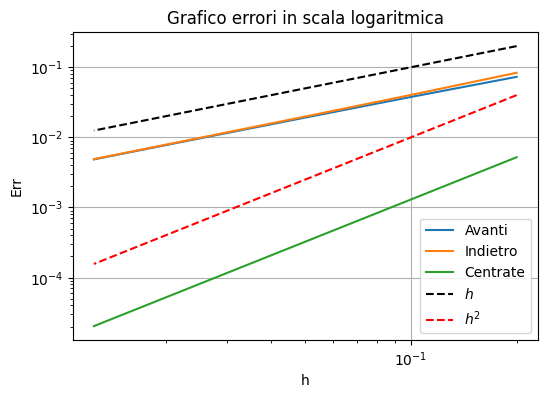

In [6]:
# Esercizio 2

# inizializzo errori
err={'Avanti':[], 'Indietro':[], 'Centrate':[]}
hlist = np.array([0.2,0.1,0.05,0.025,0.0125])

# calcolo errori 
for h in hlist:
    dfAvanti   = (f(x0+h)-f(x0))/h
    dfIndietro = (f(x0)-f(x0-h))/h
    dfCentrata = (f(x0+h)-f(x0-h))/(2*h)

    err['Avanti'].append(abs(dfEx-dfAvanti))
    err['Indietro'].append(abs(dfEx-dfIndietro))
    err['Centrate'].append(abs(dfEx-dfCentrata))

plt.figure(figsize = (6, 4))
for metodo in err.keys():
    plt.loglog(hlist, err[metodo], label=metodo)

plt.loglog(hlist, hlist,'k--', label = '$h$')
plt.loglog(hlist, hlist**2,'r--', label = '$h^2$')
plt.legend()
plt.title('Grafico errori in scala logaritmica')
plt.xlabel('h')
plt.ylabel('Err')
plt.grid()
plt.show()


**Commento** (Perché usare una scala logaritmica?)

Il motivo di questa scelta è legato alla forma in cui si presentano le stime dell'errore viste a teoria. Infatti, dalla teoria sappiamo che l'errore delle formule alle differenze finite è della forma:

$$|f'(x_{0})-(D_{h}f)(x_0)|=Ch^p,$$

dove $h$ è il passo di discretizzazione della formula, $D_{h}f$ è la discretizzazione alle differenzie finite (in avanti, all'indietro o centrate), mentre $C$ è una costante indpendente da $h$. Applicando il logaritmo ad ambo i membri dell'uguaglianza, possiamo riscrivere la stima come

$$\log{|f'(x_{0})-(D_{h}f)(x_0)|}= \log{C}+p\log{h}.$$

Ne deduciamo quindi che, il logaritmo dell'errore dipende dal logaritmo del passo in maniera affine. In particolare, il grafico del logaritmo dell'errore, inteso come funzione di $\log{h}$, è costituito da una retta con intercetta $\log{C}$ e pendenza $p$. Questo ci dice che per confrontare agevolmente gli ordini di convergenza delle diverse formule è sufficiente confrontare le pendenze delle rette che si ottengono in un grafico a scala logaritmica (su entrambi gli assi).

# Esercizi per casa

<mark>**Esercizio 3**</mark></br>
Ripetere l'analisi proposta all'**Esercizio 2**, ma avendo posto $f(x)=4(x-0.25)|x-0.25|$, sapendo che tale funzione è derivabile in $x_{0}=0.25$, e che $f'(x_0)=0.0$. Cosa si osserva? Perché?

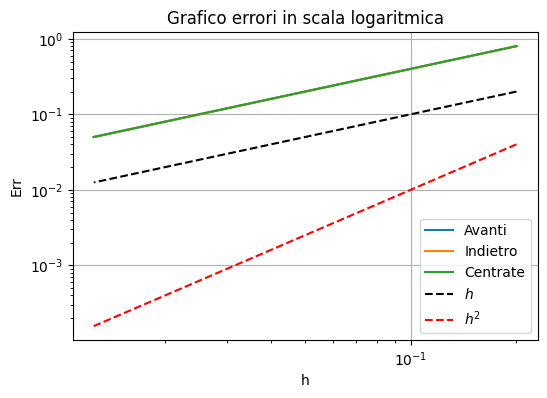

In [8]:
x0=0.25
f=lambda x: 4*(x-0.25)*abs(x-0.25)
dfEx=0.0
hlist=np.array([0.2, 0.1, 0.05, 0.025, 0.0125])
err={'Avanti':[], 'Indietro':[], 'Centrate':[]}
for h in hlist:
    dfAvanti   = (f(x0+h)-f(x0))/h
    dfIndietro = (f(x0)-f(x0-h))/h
    dfCentrata = (f(x0+h)-f(x0-h))/(2*h)

    err['Avanti'].append(abs(dfEx-dfAvanti))
    err['Indietro'].append(abs(dfEx-dfIndietro))
    err['Centrate'].append(abs(dfEx-dfCentrata))

plt.figure(figsize = (6, 4))
for metodo in err.keys():
    plt.loglog(hlist, err[metodo], label=metodo)

plt.loglog(hlist, hlist,'k--', label = '$h$')
plt.loglog(hlist, hlist**2,'r--', label = '$h^2$')
plt.legend()
plt.title('Grafico errori in scala logaritmica')
plt.xlabel('h')
plt.ylabel('Err')
plt.grid()
plt.show()